# 07. Community Perception Ablation

## 1. 분석 목적

이번 분석의 핵심 질문은 다음과 같다.

> 향의 구조가 비슷한 향수 중에서 사용자들이 비슷한 계절과 시간대에 어울린다고 평가한 향수를 우선적으로 추천하면 실제 `reminds_me_of` 관계 복원 성능이 개선되는가?

변경하지 않는 요소:

- Raw Accord Cosine
- IDF Weighted Union Note Jaccard
- Accord : Note = 0.5 : 0.5
- Top / Middle / Base Tier 사용하지 않음
- Relevant Pair 기준
- Development / Final Holdout split

새롭게 추가하는 정보는 **Season과 Daypart**뿐이다. Community Gender, Longevity, Sillage, Rating, Popularity, LLM, Embedding, 머신러닝 모델은 추천 score에 추가하지 않는다. Popularity는 뒤의 robustness 분석에서 query 그룹을 나누는 용도로만 사용한다.

`reminds_me_of`는 평가 label로만 사용하며 추천 score에는 포함하지 않는다. Final Holdout 300개는 ID만 재현하고 추천 생성이나 성능 평가에 사용하지 않는다.

## 2. 환경 설정

In [1]:
import array
import collections
import gc
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from tqdm import tqdm

SEED = 42
N_FOLDS = 5
MAX_K = 20
CANDIDATE_K = 200
BATCH_SIZE = 8
BOOTSTRAP_RESAMPLES = 2000
GAMMAS = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])
SEASON_NAMES = ("winter", "spring", "summer", "autumn")
DAYPART_NAMES = ("day", "night")

jsonl_path = pathlib.Path.cwd() / "perfumes.jsonl"
assert jsonl_path.is_file(), f"파일을 찾을 수 없습니다: {jsonl_path}"
print(f"데이터: {jsonl_path.name} ({jsonl_path.stat().st_size / (1024 ** 2):,.2f} MB)")

데이터: perfumes.jsonl (485.94 MB)


## 3. 데이터 로드

Season / Daypart는 raw vote count를 similarity vector로 쓰지 않는다. 이 셀에서는 투표 수를 보존하고, 뒤에서 각 영역의 합으로 나눈 share를 만든다. 원본 block이 없거나 합계가 0인 경우에는 missing으로 유지한다.

In [2]:
perfume_ids = array.array("i")
perfume_names, perfume_brands = [], []
popularity_values = array.array("f")
has_accord, has_note = array.array("b"), array.array("b")

accord_to_col = {}
accord_rows, accord_cols, accord_data = array.array("I"), array.array("I"), array.array("f")
note_to_col = {}
note_rows, note_cols = array.array("I"), array.array("I")

season_vote_rows = []
daypart_vote_rows = []

relation_source_ids, relation_target_ids = array.array("i"), array.array("i")
relation_up_votes, relation_down_votes = array.array("i"), array.array("i")

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in tqdm(file, desc="JSONL load", unit=" perfumes", mininterval=2.0):
        if not line.strip():
            continue

        row_index = len(perfume_ids)
        record = json.loads(line)
        perfume_id = int(record["id"])
        perfume_ids.append(perfume_id)
        perfume_names.append(record.get("name") or "")
        perfume_brands.append(record.get("brand") or "")

        magnitude = (record.get("popularity") or {}).get("magnitude")
        popularity_values.append(float(magnitude) if magnitude is not None else np.nan)

        accord_strengths = {}
        for item in record.get("accords") or []:
            name, strength = item.get("name"), item.get("strength")
            if name and strength is not None:
                col = accord_to_col.setdefault(name, len(accord_to_col))
                accord_strengths[col] = float(strength)
        has_accord.append(bool(accord_strengths))
        for col, strength in accord_strengths.items():
            accord_rows.append(row_index)
            accord_cols.append(col)
            accord_data.append(strength)

        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        note_names = set()
        for position in ("top", "middle", "base"):
            note_names.update(
                item.get("name") for item in tiered.get(position) or [] if item.get("name")
            )
        note_names.update(item.get("name") for item in notes.get("flat") or [] if item.get("name"))
        has_note.append(bool(note_names))
        for name in note_names:
            note_rows.append(row_index)
            note_cols.append(note_to_col.setdefault(name, len(note_to_col)))

        seasons = record.get("seasons") or {}
        season_vote_rows.append([int(seasons.get(name, 0) or 0) for name in SEASON_NAMES])
        daypart = record.get("daypart") or {}
        daypart_vote_rows.append([int(daypart.get(name, 0) or 0) for name in DAYPART_NAMES])

        for relation in (record.get("similar") or {}).get("reminds_me_of") or []:
            target_id = relation.get("id")
            up_votes, down_votes = relation.get("up_votes"), relation.get("down_votes")
            relation_source_ids.append(perfume_id)
            relation_target_ids.append(int(target_id) if target_id is not None else -1)
            relation_up_votes.append(int(up_votes) if up_votes is not None else -1)
            relation_down_votes.append(int(down_votes) if down_votes is not None else -1)

perfume_ids = np.asarray(perfume_ids, dtype=np.int32)
popularity = np.asarray(popularity_values, dtype=np.float32)
has_accord = np.asarray(has_accord, dtype=bool)
has_note = np.asarray(has_note, dtype=bool)
season_votes = np.asarray(season_vote_rows, dtype=np.int32)
daypart_votes = np.asarray(daypart_vote_rows, dtype=np.int32)
id_to_row = {int(perfume_id): row for row, perfume_id in enumerate(perfume_ids)}
n_perfumes = len(perfume_ids)

print(f"향수 수: {n_perfumes:,}")
print(f"고유 Accord 수: {len(accord_to_col):,}")
print(f"고유 Union Note 수: {len(note_to_col):,}")
print(f"directed reminds_me_of 수: {len(relation_source_ids):,}")
assert len(accord_to_col) == 92, "기존 Notebook의 92개 Accord 구조와 다릅니다."

JSONL load: 0 perfumes [00:00, ? perfumes/s]

JSONL load: 131930 perfumes [00:08, 15743.82 perfumes/s]

향수 수: 131,930
고유 Accord 수: 92
고유 Union Note 수: 2,523
directed reminds_me_of 수: 692,729


## 4. 평가 데이터 재현

In [3]:
directed_relations = pd.DataFrame({
    "source_id": np.asarray(relation_source_ids, dtype=np.int32),
    "target_id": np.asarray(relation_target_ids, dtype=np.int32),
    "up_votes": np.asarray(relation_up_votes, dtype=np.int32),
    "down_votes": np.asarray(relation_down_votes, dtype=np.int32),
})
valid = directed_relations[
    (directed_relations["source_id"] > 0)
    & (directed_relations["target_id"] > 0)
    & (directed_relations["up_votes"] >= 0)
    & (directed_relations["down_votes"] >= 0)
].copy()
valid["pair_low"] = np.minimum(valid["source_id"], valid["target_id"])
valid["pair_high"] = np.maximum(valid["source_id"], valid["target_id"])
pair_relations = valid.groupby(["pair_low", "pair_high"], sort=False, as_index=False)[
    ["up_votes", "down_votes"]
].sum()
pair_relations["total_votes"] = pair_relations["up_votes"] + pair_relations["down_votes"]
pair_relations["agree_ratio"] = np.divide(
    pair_relations["up_votes"], pair_relations["total_votes"],
    out=np.full(len(pair_relations), np.nan),
    where=pair_relations["total_votes"].to_numpy() > 0,
)
relevant_pairs_all = pair_relations[
    (pair_relations["pair_low"] != pair_relations["pair_high"])
    & (pair_relations["total_votes"] >= 20)
    & (pair_relations["agree_ratio"] >= 0.8)
].copy()
inside_mask = (
    relevant_pairs_all["pair_low"].isin(id_to_row)
    & relevant_pairs_all["pair_high"].isin(id_to_row)
)
relevant_pairs = relevant_pairs_all.loc[inside_mask].copy()

relevant_by_query = collections.defaultdict(set)
for low, high in relevant_pairs[["pair_low", "pair_high"]].itertuples(index=False, name=None):
    low, high = int(low), int(high)
    relevant_by_query[low].add(high)
    relevant_by_query[high].add(low)

eligible_query_ids = np.array(sorted(
    query_id for query_id, items in relevant_by_query.items()
    if len(items) >= 2 and has_accord[id_to_row[query_id]] and has_note[id_to_row[query_id]]
), dtype=np.int32)

selection_rng = np.random.default_rng(SEED)
selected_query_ids = selection_rng.choice(eligible_query_ids, size=1000, replace=False)
split_rng = np.random.default_rng(SEED)
selected_query_ids = split_rng.permutation(selected_query_ids)
development_query_ids = selected_query_ids[:700]
final_holdout_query_ids = selected_query_ids[700:]

expected_development_head = [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
expected_holdout_head = [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
assert development_query_ids[:10].tolist() == expected_development_head
assert final_holdout_query_ids[:10].tolist() == expected_holdout_head
assert len(development_query_ids) == 700 and len(final_holdout_query_ids) == 300
assert set(development_query_ids).isdisjoint(final_holdout_query_ids)

display(pd.Series({
    "Relevant Pair 수": len(relevant_pairs_all),
    "평가 가능 Query 수": len(eligible_query_ids),
    "Development Query 수": len(development_query_ids),
    "Holdout Query 수": len(final_holdout_query_ids),
}).to_frame("값"))
print("Development Query ID 앞 10개:", development_query_ids[:10].tolist())
print("Holdout Query ID 앞 10개:", final_holdout_query_ids[:10].tolist())
print("06 Notebook과 동일한 split임을 앞 10개 ID 및 assert로 확인했습니다.")
print("Final Holdout은 아래의 추천/평가 함수에 전달하지 않습니다.")

del directed_relations, valid, pair_relations
del relation_source_ids, relation_target_ids, relation_up_votes, relation_down_votes
gc.collect()

,값
Relevant Pair 수,10770
평가 가능 Query 수,3835
Development Query 수,700
Holdout Query 수,300


Development Query ID 앞 10개: [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
Holdout Query ID 앞 10개: [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
06 Notebook과 동일한 split임을 앞 10개 ID 및 assert로 확인했습니다.
Final Holdout은 아래의 추천/평가 함수에 전달하지 않습니다.


0

## 5. Development 5-Fold 구성

In [4]:
cv_rng = np.random.default_rng(SEED)
cv_permuted = cv_rng.permutation(development_query_ids)
cv_folds = [part.astype(np.int32, copy=False) for part in np.array_split(cv_permuted, N_FOLDS)]
development_rows = np.array([id_to_row[int(q)] for q in development_query_ids], dtype=np.int32)

assert [len(fold) for fold in cv_folds] == [140] * 5
assert set(np.concatenate(cv_folds)) == set(development_query_ids)
pd.DataFrame({"fold": np.arange(1, 6), "query_count": [len(fold) for fold in cv_folds]})

,fold,query_count
0,1,140
1,2,140
2,3,140
3,4,140
4,5,140


## 6. Community 데이터 Coverage

In [5]:
season_totals = season_votes.sum(axis=1).astype(np.int32)
daypart_totals = daypart_votes.sum(axis=1).astype(np.int32)

def coverage_table(rows, label):
    result = []
    for feature, totals in (("Season", season_totals), ("Daypart", daypart_totals)):
        for threshold in (1, 10, 20, 50, 100):
            count = int((totals[rows] >= threshold).sum())
            result.append({
                "dataset": label,
                "feature": feature,
                "condition": "> 0" if threshold == 1 else f">= {threshold}",
                "perfume_count": count,
                "ratio": count / len(rows),
            })
    return pd.DataFrame(result)

all_rows = np.arange(n_perfumes, dtype=np.int32)
coverage_df = pd.concat([
    coverage_table(all_rows, "전체 향수"),
    coverage_table(development_rows, "Development 700"),
], ignore_index=True)
display(coverage_df.assign(ratio=lambda x: x["ratio"].map(lambda v: f"{v:.2%}")))

,dataset,feature,condition,perfume_count,ratio
0,전체 향수,Season,> 0,111351,84.40%
1,전체 향수,Season,>= 10,74601,56.55%
2,전체 향수,Season,>= 20,57533,43.61%
3,전체 향수,Season,>= 50,37880,28.71%
4,전체 향수,Season,>= 100,25515,19.34%
5,전체 향수,Daypart,> 0,109559,83.04%
6,전체 향수,Daypart,>= 10,60416,45.79%
7,전체 향수,Daypart,>= 20,44421,33.67%
8,전체 향수,Daypart,>= 50,27080,20.53%
9,전체 향수,Daypart,>= 100,17113,12.97%


## 7. Season / Daypart Share와 Cosine 표현

In [6]:
season_shares = np.full((n_perfumes, 4), np.nan, dtype=np.float32)
daypart_shares = np.full((n_perfumes, 2), np.nan, dtype=np.float32)

valid_season = season_totals > 0
valid_daypart = daypart_totals > 0
season_shares[valid_season] = season_votes[valid_season] / season_totals[valid_season, None]
daypart_shares[valid_daypart] = daypart_votes[valid_daypart] / daypart_totals[valid_daypart, None]

season_unit = np.full_like(season_shares, np.nan)
daypart_unit = np.full_like(daypart_shares, np.nan)
season_norms = np.linalg.norm(season_shares[valid_season], axis=1)
daypart_norms = np.linalg.norm(daypart_shares[valid_daypart], axis=1)
season_unit[valid_season] = season_shares[valid_season] / season_norms[:, None]
daypart_unit[valid_daypart] = daypart_shares[valid_daypart] / daypart_norms[:, None]

assert np.isnan(season_shares[~valid_season]).all()
assert np.isnan(daypart_shares[~valid_daypart]).all()
assert np.allclose(season_shares[valid_season].sum(axis=1), 1.0)
assert np.allclose(daypart_shares[valid_daypart].sum(axis=1), 1.0)

display(pd.DataFrame({
    "feature": ["Season", "Daypart"],
    "valid_vectors": [int(valid_season.sum()), int(valid_daypart.sum())],
    "missing_vectors": [int((~valid_season).sum()), int((~valid_daypart).sum())],
}))
print("Missing vector는 NaN으로 유지하며 0 vector로 바꾸지 않았습니다.")

,feature,valid_vectors,missing_vectors
0,Season,111351,20579
1,Daypart,109559,22371


Missing vector는 NaN으로 유지하며 0 vector로 바꾸지 않았습니다.


## 8. Season / Daypart / Combined Community Similarity

- Season Only: 두 향수 모두 유효할 때 4차원 share vector의 cosine
- Daypart Only: 두 향수 모두 유효할 때 2차원 share vector의 cosine
- Season + Daypart: 둘 다 있으면 각 similarity를 0.5 : 0.5로 결합하고, 하나만 있으면 존재하는 값을 사용
- 둘 다 없으면 NaN

Reliable-vote에서는 각 similarity를 구성하는 두 향수의 해당 total이 모두 20 이상일 때만 사용한다. 20은 이전 EDA와 연결한 탐색 기준이며 절대적인 정답 기준이 아니다.

In [7]:
def community_similarities(rows_a, rows_b, minimum_votes=1):
    rows_a = np.asarray(rows_a, dtype=np.int32)
    rows_b = np.asarray(rows_b, dtype=np.int32)
    season_similarity = np.full(len(rows_a), np.nan, dtype=np.float32)
    daypart_similarity = np.full(len(rows_a), np.nan, dtype=np.float32)

    season_ok = (season_totals[rows_a] >= minimum_votes) & (season_totals[rows_b] >= minimum_votes)
    daypart_ok = (daypart_totals[rows_a] >= minimum_votes) & (daypart_totals[rows_b] >= minimum_votes)
    season_similarity[season_ok] = np.einsum(
        "ij,ij->i", season_unit[rows_a[season_ok]], season_unit[rows_b[season_ok]]
    )
    daypart_similarity[daypart_ok] = np.einsum(
        "ij,ij->i", daypart_unit[rows_a[daypart_ok]], daypart_unit[rows_b[daypart_ok]]
    )

    combined = np.full(len(rows_a), np.nan, dtype=np.float32)
    both = np.isfinite(season_similarity) & np.isfinite(daypart_similarity)
    season_only = np.isfinite(season_similarity) & ~np.isfinite(daypart_similarity)
    daypart_only = ~np.isfinite(season_similarity) & np.isfinite(daypart_similarity)
    combined[both] = 0.5 * season_similarity[both] + 0.5 * daypart_similarity[both]
    combined[season_only] = season_similarity[season_only]
    combined[daypart_only] = daypart_similarity[daypart_only]
    return season_similarity, daypart_similarity, combined

## 9. Community 정보 자체의 Diagnostic 분석

In [8]:
development_id_set = set(map(int, development_query_ids))
development_pair_mask = (
    relevant_pairs["pair_low"].isin(development_id_set)
    | relevant_pairs["pair_high"].isin(development_id_set)
)
development_pairs = relevant_pairs.loc[development_pair_mask, ["pair_low", "pair_high"]]
relevant_rows_a = np.array([id_to_row[int(x)] for x in development_pairs["pair_low"]], dtype=np.int32)
relevant_rows_b = np.array([id_to_row[int(x)] for x in development_pairs["pair_high"]], dtype=np.int32)

diagnostic_rng = np.random.default_rng(SEED)
random_rows_a = diagnostic_rng.integers(0, n_perfumes, size=len(development_pairs), dtype=np.int32)
random_rows_b = diagnostic_rng.integers(0, n_perfumes, size=len(development_pairs), dtype=np.int32)
self_pairs = random_rows_a == random_rows_b
while self_pairs.any():
    random_rows_b[self_pairs] = diagnostic_rng.integers(0, n_perfumes, size=int(self_pairs.sum()), dtype=np.int32)
    self_pairs = random_rows_a == random_rows_b

diagnostic_rows = []
diagnostic_values = {}
for pair_group, rows_a, rows_b in (
    ("Relevant Pair", relevant_rows_a, relevant_rows_b),
    ("Random Pair", random_rows_a, random_rows_b),
):
    similarities = community_similarities(rows_a, rows_b, minimum_votes=1)
    for feature, values in zip(("Season", "Daypart", "Combined"), similarities):
        finite = values[np.isfinite(values)]
        diagnostic_values[(pair_group, feature)] = finite
        diagnostic_rows.append({
            "pair_group": pair_group,
            "feature": feature,
            "sampled_pair_count": len(rows_a),
            "valid_similarity_count": len(finite),
            "mean": finite.mean() if len(finite) else np.nan,
            "median": np.median(finite) if len(finite) else np.nan,
        })

diagnostic_df = pd.DataFrame(diagnostic_rows)
display(diagnostic_df.round(4))
display(Markdown(
    "Random Pair는 negative ground truth가 아니다. Relevant Pair의 Community Similarity가 일반적인 무작위 pair보다 "
    "높은 경향이 있는지 확인하기 위한 비교 기준이다."
))

,pair_group,feature,sampled_pair_count,valid_similarity_count,mean,median
0,Relevant Pair,Season,2227,2223,0.9694,0.9881
1,Relevant Pair,Daypart,2227,2224,0.9799,0.9943
2,Relevant Pair,Combined,2227,2224,0.9746,0.9895
3,Random Pair,Season,2227,1583,0.7671,0.8351
4,Random Pair,Daypart,2227,1534,0.8644,0.9350
5,Random Pair,Combined,2227,1606,0.8094,0.8656


Random Pair는 negative ground truth가 아니다. Relevant Pair의 Community Similarity가 일반적인 무작위 pair보다 높은 경향이 있는지 확인하기 위한 비교 기준이다.

## 10. Community Vote Confidence

- **Any-vote:** 해당 영역의 두 향수 total이 모두 1 이상이면 사용
- **Reliable-vote:** 해당 영역의 두 향수 total이 모두 20 이상이면 사용

조건을 만족하지 않으면 similarity는 NaN이며, 뒤의 reranking에서는 Base score로 fallback한다. `>=20`은 EDA에서 사용한 탐색 기준이지 절대적인 품질 기준이 아니다.

## 11. Community를 직접 Retrieval에 사용하지 않는 이유

Season / Daypart는 향의 화학적·구조적 구성보다 **어떤 상황에 어울린다고 느끼는가**에 가까운 정보다. Community Similarity만으로 전체 13만 개 향수에서 후보를 검색하면 사용 상황은 비슷하지만 향 자체는 다른 향수가 상위에 올라올 수 있다.

따라서 이번 실험에서는 Community 정보를 기존 향 구조 기반 추천의 **Reranking Feature**로만 사용한다.

## 12. 현재 Baseline과 Base TOP 200 Candidate Pool

In [9]:
def binary_csr(rows, cols, shape):
    matrix = sparse.csr_matrix(
        (np.ones(len(rows), dtype=np.float32),
         (np.asarray(rows, dtype=np.int32), np.asarray(cols, dtype=np.int32))),
        shape=shape, dtype=np.float32,
    )
    matrix.sum_duplicates()
    matrix.data[:] = 1.0
    return matrix

def row_normalize(matrix):
    norms = np.sqrt(matrix.multiply(matrix).sum(axis=1)).A1.astype(np.float32)
    inverse = np.zeros_like(norms)
    np.divide(1.0, norms, out=inverse, where=norms > 0)
    return matrix.multiply(inverse[:, None]).tocsr()

def top_k_rows(score_vector, k):
    scores = np.nan_to_num(np.asarray(score_vector), nan=-np.inf)
    k = min(k, scores.size)
    preliminary = np.argpartition(-scores, kth=k - 1)[:k]
    threshold = scores[preliminary].min()
    higher = np.flatnonzero(scores > threshold)
    tied = np.flatnonzero(scores == threshold)
    needed = k - len(higher)
    if needed < len(tied):
        tied = tied[np.argpartition(perfume_ids[tied], needed - 1)[:needed]]
    selected = np.concatenate([higher, tied[:needed]])
    order = np.lexsort((perfume_ids[selected], -scores[selected]))
    return selected[order].astype(np.int32, copy=False)

X_accord_raw = sparse.csr_matrix(
    (np.asarray(accord_data, dtype=np.float32),
     (np.asarray(accord_rows, dtype=np.int32), np.asarray(accord_cols, dtype=np.int32))),
    shape=(n_perfumes, len(accord_to_col)), dtype=np.float32,
)
X_notes = binary_csr(note_rows, note_cols, (n_perfumes, len(note_to_col)))
X_accord = row_normalize(X_accord_raw)

note_df = np.asarray(X_notes.sum(axis=0)).ravel().astype(np.int32)
note_idf = (np.log((n_perfumes + 1) / (note_df + 1)) + 1).astype(np.float32)
X_note_weighted = X_notes.multiply(note_idf).tocsr()
note_weight_sums = np.asarray(X_note_weighted.sum(axis=1)).ravel().astype(np.float32)

base_candidates = {}
base_candidate_scores = {}
baseline_rankings = {}

for start in tqdm(range(0, len(development_query_ids), BATCH_SIZE), desc="Base TOP 200", mininterval=2.0):
    query_ids = development_query_ids[start:start + BATCH_SIZE]
    query_rows = np.array([id_to_row[int(q)] for q in query_ids], dtype=np.int32)
    accord_scores = (X_accord[query_rows] @ X_accord.T).toarray().astype(np.float32, copy=False)
    intersection = (X_note_weighted[query_rows] @ X_notes.T).toarray()
    union = note_weight_sums[query_rows, None] + note_weight_sums[None, :] - intersection
    note_scores = np.zeros(intersection.shape, dtype=np.float32)
    np.divide(intersection, union, out=note_scores, where=union > 0)
    base_scores = 0.5 * accord_scores + 0.5 * note_scores

    for i, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id, query_row = int(query_id), int(query_row)
        base_scores[i, query_row] = -np.inf
        candidate_rows = top_k_rows(base_scores[i], CANDIDATE_K)
        base_candidates[query_id] = candidate_rows
        base_candidate_scores[query_id] = base_scores[i, candidate_rows].copy()
        baseline_rankings[query_id] = candidate_rows[:MAX_K]

    del accord_scores, intersection, union, note_scores, base_scores

print(f"Base TOP {CANDIDATE_K} 생성 query 수: {len(base_candidates):,}")
print(f"Final Holdout candidate 생성 수: {sum(int(q) in base_candidates for q in final_holdout_query_ids)}")
assert len(base_candidates) == 700
assert not any(int(q) in base_candidates for q in final_holdout_query_ids)

del X_accord_raw, accord_rows, accord_cols, accord_data, note_rows, note_cols
gc.collect()

Base TOP 200: 100%|██████████| 88/88 [00:05<00:00, 14.99it/s]

Base TOP 200 생성 query 수: 700
Final Holdout candidate 생성 수: 0


138

Base candidate는 query/batch 단위로만 계산해 TOP 200만 보존했다. 전체 `131,930 × 131,930` similarity matrix는 만들지 않았다.

Community Reranking은 이 TOP 200의 순서만 바꿀 수 있다. Relevant Item이 Base TOP 200 밖에 있으면 Community 정보로 새롭게 후보군에 들어올 수 없다는 한계가 있다.

## 13. Ranking 평가 함수와 Baseline 재현

In [10]:
def query_metric_values(recommended_rows, relevant_ids, k):
    recommended_ids = perfume_ids[recommended_rows[:k]]
    relevance = np.fromiter(
        (int(candidate_id) in relevant_ids for candidate_id in recommended_ids),
        dtype=np.int8, count=len(recommended_ids),
    )
    hits = int(relevance.sum())
    hit_positions = np.flatnonzero(relevance)
    discounts = 1.0 / np.log2(np.arange(2, len(relevance) + 2))
    ideal_length = min(len(relevant_ids), k)
    idcg = float(discounts[:ideal_length].sum())
    return {
        "recall": hits / len(relevant_ids),
        "hit_rate": float(hits > 0),
        "mrr": 1.0 / (hit_positions[0] + 1) if hit_positions.size else 0.0,
        "ndcg": float(np.dot(relevance, discounts)) / idcg if idcg > 0 else 0.0,
    }

def per_query_metrics(rankings, query_ids):
    rows = []
    for query_id in query_ids:
        query_id = int(query_id)
        for k in (10, 20):
            rows.append({
                "query_id": query_id,
                "k": k,
                **query_metric_values(rankings[query_id], relevant_by_query[query_id], k),
            })
    return pd.DataFrame(rows)

METRICS = {
    "Recall@10": ("recall", 10), "HitRate@10": ("hit_rate", 10),
    "MRR@10": ("mrr", 10), "NDCG@10": ("ndcg", 10),
    "Recall@20": ("recall", 20), "NDCG@20": ("ndcg", 20),
}

def fold_summary(detail):
    fold_rows = []
    for fold_number, fold_ids in enumerate(cv_folds, start=1):
        row = {"fold": fold_number}
        for display_name, (column, k) in METRICS.items():
            part = detail[(detail["k"] == k) & detail["query_id"].isin(fold_ids)]
            row[display_name] = part[column].mean()
        fold_rows.append(row)
    fold_df = pd.DataFrame(fold_rows)
    means = {metric: fold_df[metric].mean() for metric in METRICS}
    stds = {metric: fold_df[metric].std(ddof=1) for metric in METRICS}
    return fold_df, means, stds

baseline_per_query = per_query_metrics(baseline_rankings, development_query_ids)
baseline_fold_df, baseline_means, baseline_stds = fold_summary(baseline_per_query)
baseline_result = pd.Series({
    "Recall@10": baseline_means["Recall@10"],
    "HitRate@10": baseline_means["HitRate@10"],
    "MRR@10": baseline_means["MRR@10"],
    "NDCG@10": baseline_means["NDCG@10"],
    "Recall@20": baseline_means["Recall@20"],
    "NDCG@20": baseline_means["NDCG@20"],
})
display(baseline_result.to_frame("Development 5-Fold mean").T.round(4))
print(f"06 Notebook NDCG@10 0.2709와의 차이: {baseline_means['NDCG@10'] - 0.2709:+.6f}")
print("Final Holdout 평가 query 수: 0")

,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
Development 5-Fold mean,0.301,0.5657,0.3813,0.2709,0.35,0.2886


06 Notebook NDCG@10 0.2709와의 차이: -0.000006
Final Holdout 평가 query 수: 0


## 14. Community Reranking Score와 비교 Variant

Base TOP 200 안에서 community similarity가 있으면 다음을 사용한다.

\[
rerank\_score=(1-\gamma)\cdot base\_similarity+\gamma\cdot community\_similarity
\]

Community similarity가 NaN이면 `rerank_score = base_similarity`로 fallback한다. Missing이라는 이유로 candidate를 불이익 주지 않는다.

비교 Variant:

1. Baseline
2. Season Any-vote
3. Daypart Any-vote
4. Season + Daypart Any-vote
5. Season Reliable-vote `>=20`
6. Daypart Reliable-vote `>=20`
7. Season + Daypart Reliable-vote `>=20`

In [11]:
VARIANTS = [
    ("Season", "Any-vote", 1, 0),
    ("Daypart", "Any-vote", 1, 1),
    ("Season + Daypart", "Any-vote", 1, 2),
    ("Season", "Reliable-vote >= 20", 20, 0),
    ("Daypart", "Reliable-vote >= 20", 20, 1),
    ("Season + Daypart", "Reliable-vote >= 20", 20, 2),
]

variant_rankings = {
    (model, condition): {float(gamma): {} for gamma in GAMMAS}
    for model, condition, _, _ in VARIANTS
}

for query_id in tqdm(development_query_ids, desc="Community reranking", mininterval=2.0):
    query_id = int(query_id)
    query_row = id_to_row[query_id]
    candidates = base_candidates[query_id]
    base_scores = base_candidate_scores[query_id]
    query_rows = np.full(len(candidates), query_row, dtype=np.int32)

    cache = {}
    for minimum_votes in (1, 20):
        cache[minimum_votes] = community_similarities(
            query_rows, candidates, minimum_votes=minimum_votes
        )

    for model, condition, minimum_votes, similarity_index in VARIANTS:
        community_scores = cache[minimum_votes][similarity_index]
        available = np.isfinite(community_scores)
        for gamma in GAMMAS:
            gamma = float(gamma)
            rerank_scores = base_scores.copy()
            rerank_scores[available] = (
                (1.0 - gamma) * base_scores[available]
                + gamma * community_scores[available]
            )
            order = np.lexsort((perfume_ids[candidates], -rerank_scores))
            variant_rankings[(model, condition)][gamma][query_id] = candidates[order[:MAX_K]]

Community reranking: 100%|██████████| 700/700 [00:01<00:00, 577.27it/s]


## 15. Gamma 5-Fold Cross Validation

,model,vote_condition,gamma,Recall@10 mean,HitRate@10 mean,MRR@10 mean,NDCG@10 mean,Recall@20 mean,NDCG@20 mean,Recall@10 std,HitRate@10 std,MRR@10 std,NDCG@10 std,Recall@20 std,NDCG@20 std
0,Season,Any-vote,0.00,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886,0.0289,0.0533,0.0200,0.0160,0.0229,0.0140
1,Season,Any-vote,0.05,0.3044,0.5671,0.3865,0.2755,0.3591,0.2952,0.0285,0.0536,0.0225,0.0153,0.0233,0.0125
2,Season,Any-vote,0.10,0.3074,0.5686,0.3903,0.2790,0.3686,0.3007,0.0274,0.0526,0.0198,0.0150,0.0213,0.0118
3,Season,Any-vote,0.15,0.3142,0.5743,0.3954,0.2840,0.3728,0.3049,0.0288,0.0519,0.0193,0.0144,0.0238,0.0123
4,Season,Any-vote,0.20,0.3200,0.5829,0.3983,0.2874,0.3737,0.3070,0.0266,0.0526,0.0189,0.0129,0.0228,0.0120
5,Season,Any-vote,0.25,0.3209,0.5814,0.4022,0.2898,0.3755,0.3097,0.0228,0.0470,0.0172,0.0117,0.0233,0.0125
6,Season,Any-vote,0.30,0.3241,0.5871,0.4071,0.2934,0.3778,0.3128,0.0229,0.0475,0.0188,0.0121,0.0233,0.0127
7,Season,Any-vote,0.40,0.3285,0.5943,0.4137,0.2983,0.3833,0.3176,0.0235,0.0439,0.0205,0.0125,0.0246,0.0140
8,Season,Any-vote,0.50,0.3290,0.5929,0.4186,0.3017,0.3858,0.3217,0.0176,0.0346,0.0176,0.0123,0.0228,0.0138
9,Daypart,Any-vote,0.00,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886,0.0289,0.0533,0.0200,0.0160,0.0229,0.0140


Season / Any-vote: Development CV에서 선택된 후보 gamma=0.50
Daypart / Any-vote: Development CV에서 선택된 후보 gamma=0.50
Season + Daypart / Any-vote: Development CV에서 선택된 후보 gamma=0.50
Season / Reliable-vote >= 20: Development CV에서 선택된 후보 gamma=0.50
Daypart / Reliable-vote >= 20: Development CV에서 선택된 후보 gamma=0.50
Season + Daypart / Reliable-vote >= 20: Development CV에서 선택된 후보 gamma=0.50


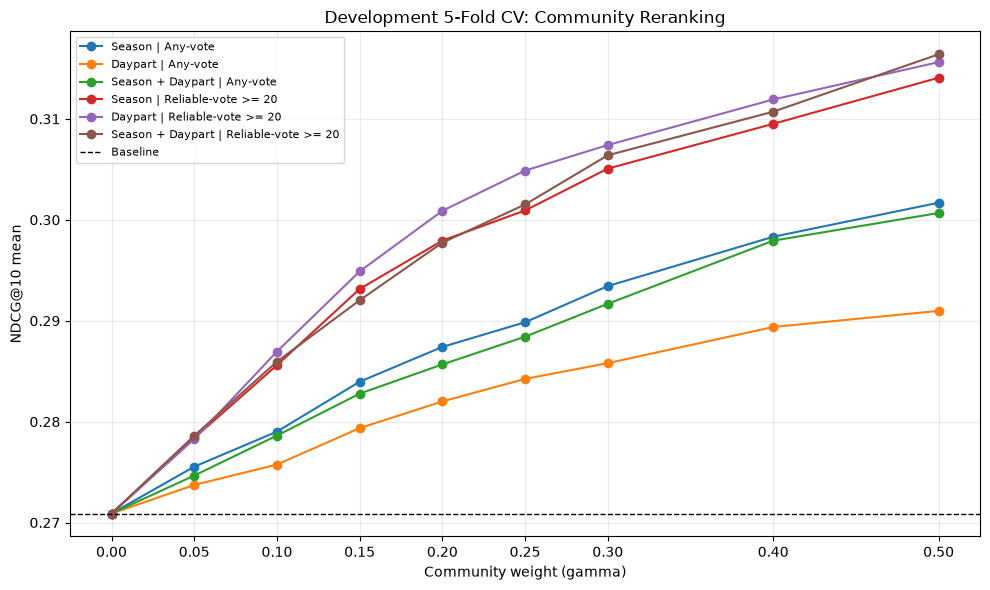

In [12]:
variant_per_query = {}
variant_fold_results = {}
gamma_rows = []

for model, condition, _, _ in VARIANTS:
    key = (model, condition)
    for gamma in GAMMAS:
        gamma = float(gamma)
        detail = per_query_metrics(variant_rankings[key][gamma], development_query_ids)
        fold_df, means, stds = fold_summary(detail)
        variant_per_query[(model, condition, gamma)] = detail
        variant_fold_results[(model, condition, gamma)] = fold_df
        gamma_rows.append({
            "model": model,
            "vote_condition": condition,
            "gamma": gamma,
            **{f"{metric} mean": means[metric] for metric in METRICS},
            **{f"{metric} std": stds[metric] for metric in METRICS},
        })

gamma_results_df = pd.DataFrame(gamma_rows)
display(gamma_results_df.round(4))

selected_variant_rows = []
for model, condition, _, _ in VARIANTS:
    part = gamma_results_df[
        (gamma_results_df["model"] == model)
        & (gamma_results_df["vote_condition"] == condition)
    ]
    selected = part.sort_values(
        ["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean", "gamma"],
        ascending=[False, False, False, True],
    ).iloc[0]
    selected_variant_rows.append(selected)
    print(
        f"{model} / {condition}: Development CV에서 선택된 후보 gamma="
        f"{selected['gamma']:.2f}"
    )

selected_variants_df = pd.DataFrame(selected_variant_rows).reset_index(drop=True)

plt.figure(figsize=(10, 6))
for (model, condition), part in gamma_results_df.groupby(["model", "vote_condition"], sort=False):
    plt.plot(part["gamma"], part["NDCG@10 mean"], marker="o", label=f"{model} | {condition}")
plt.axhline(baseline_means["NDCG@10"], color="black", linestyle="--", linewidth=1, label="Baseline")
plt.xlabel("Community weight (gamma)")
plt.ylabel("NDCG@10 mean")
plt.title("Development 5-Fold CV: Community Reranking")
plt.xticks(GAMMAS)
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 16. Community Variant 비교

In [13]:
comparison_rows = [{
    "model": "Baseline",
    "vote_condition": "None",
    "selected_gamma": 0.0,
    "Recall@10_mean": baseline_means["Recall@10"],
    "Recall@10_std": baseline_stds["Recall@10"],
    "HitRate@10_mean": baseline_means["HitRate@10"],
    "MRR@10_mean": baseline_means["MRR@10"],
    "NDCG@10_mean": baseline_means["NDCG@10"],
    "NDCG@10_std": baseline_stds["NDCG@10"],
    "Recall@20_mean": baseline_means["Recall@20"],
    "NDCG@20_mean": baseline_means["NDCG@20"],
}]

for _, row in selected_variants_df.iterrows():
    comparison_rows.append({
        "model": row["model"],
        "vote_condition": row["vote_condition"],
        "selected_gamma": row["gamma"],
        "Recall@10_mean": row["Recall@10 mean"],
        "Recall@10_std": row["Recall@10 std"],
        "HitRate@10_mean": row["HitRate@10 mean"],
        "MRR@10_mean": row["MRR@10 mean"],
        "NDCG@10_mean": row["NDCG@10 mean"],
        "NDCG@10_std": row["NDCG@10 std"],
        "Recall@20_mean": row["Recall@20 mean"],
        "NDCG@20_mean": row["NDCG@20 mean"],
    })

variant_comparison_df = pd.DataFrame(comparison_rows)
display(variant_comparison_df.round(4))

,model,vote_condition,selected_gamma,Recall@10_mean,Recall@10_std,HitRate@10_mean,MRR@10_mean,NDCG@10_mean,NDCG@10_std,Recall@20_mean,NDCG@20_mean
0,Baseline,None,0.0,0.3010,0.0289,0.5657,0.3813,0.2709,0.0160,0.3500,0.2886
1,Season,Any-vote,0.5,0.3290,0.0176,0.5929,0.4186,0.3017,0.0123,0.3858,0.3217
2,Daypart,Any-vote,0.5,0.3222,0.0205,0.5857,0.4060,0.2910,0.0127,0.3754,0.3108
3,Season + Daypart,Any-vote,0.5,0.3296,0.0219,0.6000,0.4170,0.3007,0.0121,0.3870,0.3214
4,Season,Reliable-vote >= 20,0.5,0.3435,0.0266,0.6157,0.4304,0.3141,0.0170,0.3981,0.3338
5,Daypart,Reliable-vote >= 20,0.5,0.3443,0.0257,0.6086,0.4342,0.3156,0.0127,0.3923,0.3331
6,Season + Daypart,Reliable-vote >= 20,0.5,0.3457,0.0254,0.6186,0.4341,0.3164,0.0148,0.4013,0.3365


## 17. Best Community Candidate 선택

In [14]:
best_community_row = selected_variants_df.sort_values(
    ["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean", "gamma", "model", "vote_condition"],
    ascending=[False, False, False, True, True, True],
).iloc[0]

if best_community_row["NDCG@10 mean"] > baseline_means["NDCG@10"] + 1e-12:
    selected_is_baseline = False
    selected_model = str(best_community_row["model"])
    selected_condition = str(best_community_row["vote_condition"])
    selected_gamma = float(best_community_row["gamma"])
    selected_rankings = variant_rankings[(selected_model, selected_condition)][selected_gamma]
    selected_per_query = variant_per_query[(selected_model, selected_condition, selected_gamma)]
    selected_fold_df = variant_fold_results[(selected_model, selected_condition, selected_gamma)]
    selected_means = {metric: float(best_community_row[f"{metric} mean"]) for metric in METRICS}
    selected_stds = {metric: float(best_community_row[f"{metric} std"]) for metric in METRICS}
    selection_message = "Community Feature 후보를 선택"
else:
    selected_is_baseline = True
    selected_model = "None (Baseline)"
    selected_condition = "None"
    selected_gamma = 0.0
    selected_rankings = baseline_rankings
    selected_per_query = baseline_per_query
    selected_fold_df = baseline_fold_df
    selected_means = baseline_means.copy()
    selected_stds = baseline_stds.copy()
    selection_message = "Community Feature를 추가하지 않는 것이 가장 좋음"

display(pd.Series({
    "Development CV 기준 Community Feature 후보": selected_model,
    "vote condition": selected_condition,
    "gamma": selected_gamma,
    "NDCG@10": selected_means["NDCG@10"],
    "판단": selection_message,
}).to_frame("값"))
print("최종 가중치가 아니라 Development CV 기준 후보 선택입니다.")

,값
Development CV 기준 Community Feature 후보,Season + Daypart
vote condition,Reliable-vote >= 20
gamma,0.5
NDCG@10,0.316402
판단,Community Feature 후보를 선택


최종 가중치가 아니라 Development CV 기준 후보 선택입니다.


## 18. Fold별 성능 변화

In [15]:
fold_metrics = ["Recall@10", "HitRate@10", "MRR@10", "NDCG@10"]
fold_difference_df = selected_fold_df[["fold", *fold_metrics]].copy()
fold_difference_df[fold_metrics] = selected_fold_df[fold_metrics] - baseline_fold_df[fold_metrics]
display(fold_difference_df.round(4))

fold_direction_rows = []
for metric in fold_metrics:
    values = fold_difference_df[metric].to_numpy()
    fold_direction_rows.append({
        "metric": metric,
        "개선 Fold 수": int((values > 1e-12).sum()),
        "하락 Fold 수": int((values < -1e-12).sum()),
        "동일 Fold 수": int((np.abs(values) <= 1e-12).sum()),
    })
fold_direction_df = pd.DataFrame(fold_direction_rows)
display(fold_direction_df)

,fold,Recall@10,HitRate@10,MRR@10,NDCG@10
0,1,0.0351,0.0429,0.0525,0.0422
1,2,0.0447,0.0357,0.0318,0.0389
2,3,0.0448,0.0714,0.0469,0.0394
3,4,0.0637,0.0786,0.0706,0.0619
4,5,0.0351,0.0357,0.0622,0.0451


,metric,개선 Fold 수,하락 Fold 수,동일 Fold 수
0,Recall@10,5,0,0
1,HitRate@10,5,0,0
2,MRR@10,5,0,0
3,NDCG@10,5,0,0


## 19. Paired Bootstrap: 개선 방향의 안정성

In [16]:
def metric_vector(detail, metric_name, k=10):
    lookup = detail[detail["k"] == k].set_index("query_id")[metric_name]
    return np.array([lookup.loc[int(q)] for q in development_query_ids], dtype=float)

bootstrap_rng = np.random.default_rng(SEED)
bootstrap_rows = []
for display_name, metric_name in (("Recall@10", "recall"), ("NDCG@10", "ndcg")):
    differences = (
        metric_vector(selected_per_query, metric_name)
        - metric_vector(baseline_per_query, metric_name)
    )
    indices = bootstrap_rng.integers(
        0, len(differences), size=(BOOTSTRAP_RESAMPLES, len(differences))
    )
    bootstrap_means = differences[indices].mean(axis=1)
    lower, upper = np.quantile(bootstrap_means, [0.025, 0.975])
    includes_zero = bool(lower <= 0 <= upper)
    bootstrap_rows.append({
        "metric": display_name,
        "mean_difference": differences.mean(),
        "ci_2.5%": lower,
        "ci_97.5%": upper,
        "CI_includes_zero": includes_zero,
        "improvement_direction_stability": (
            "개선 방향이 안정적" if lower > 0
            else "하락 방향이 안정적" if upper < 0
            else "CI가 0을 포함해 방향이 안정적이지 않음"
        ),
    })
bootstrap_df = pd.DataFrame(bootstrap_rows)
display(bootstrap_df.round(4))

,metric,mean_difference,ci_2.5%,ci_97.5%,CI_includes_zero,improvement_direction_stability
0,Recall@10,0.0447,0.0324,0.0568,False,개선 방향이 안정적
1,NDCG@10,0.0455,0.0373,0.0549,False,개선 방향이 안정적


## 20. Community Coverage에 따른 성능

In [17]:
query_season_reliable = season_totals[development_rows] >= 20
query_daypart_reliable = daypart_totals[development_rows] >= 20
coverage_groups = {
    "A. Season+Daypart 모두 충분": development_query_ids[
        query_season_reliable & query_daypart_reliable
    ],
    "B. Community vote 일부만 충분": development_query_ids[
        query_season_reliable ^ query_daypart_reliable
    ],
    "C. Community data 거의 없음": development_query_ids[
        ~query_season_reliable & ~query_daypart_reliable
    ],
}

coverage_performance_rows = []
for group_name, group_ids in coverage_groups.items():
    for model_name, detail in (("Baseline", baseline_per_query), ("Community Candidate", selected_per_query)):
        part = detail[(detail["k"] == 10) & detail["query_id"].isin(group_ids)]
        coverage_performance_rows.append({
            "group": group_name,
            "query_count": len(group_ids),
            "model": model_name,
            "Recall@10": part["recall"].mean(),
            "HitRate@10": part["hit_rate"].mean(),
            "NDCG@10": part["ndcg"].mean(),
            "interpretation_note": "그룹이 작아 해석 주의" if len(group_ids) < 30 else "",
        })
coverage_performance_df = pd.DataFrame(coverage_performance_rows)
display(coverage_performance_df.round(4))

,group,query_count,model,Recall@10,HitRate@10,NDCG@10,interpretation_note
0,A. Season+Daypart 모두 충분,673,Baseline,0.3045,0.5736,0.2739,
1,A. Season+Daypart 모두 충분,673,Community Candidate,0.3489,0.6241,0.3196,
2,B. Community vote 일부만 충분,21,Baseline,0.1421,0.2857,0.1279,그룹이 작아 해석 주의
3,B. Community vote 일부만 충분,21,Community Candidate,0.2087,0.4286,0.1791,그룹이 작아 해석 주의
4,C. Community data 거의 없음,6,Baseline,0.4667,0.6667,0.4358,그룹이 작아 해석 주의
5,C. Community data 거의 없음,6,Community Candidate,0.4667,0.6667,0.4358,그룹이 작아 해석 주의


## 21. 인기 향수 Robustness

In [18]:
popularity_frame = pd.DataFrame({
    "query_id": development_query_ids.astype(int),
    "popularity": popularity[development_rows],
}).dropna()

popularity_robustness_df = pd.DataFrame()
if popularity_frame["popularity"].nunique() < 4:
    print("고유 popularity 값이 4개 미만이라 4분위 분석을 수행하지 않습니다.")
else:
    try:
        popularity_frame["quartile"] = pd.qcut(
            popularity_frame["popularity"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="raise"
        )
        quartile_rows = []
        for quartile in ["Q1", "Q2", "Q3", "Q4"]:
            ids = popularity_frame.loc[
                popularity_frame["quartile"] == quartile, "query_id"
            ].astype(int).to_numpy()
            row = {"popularity_quartile": quartile, "query_count": len(ids)}
            for model_name, detail in (("Baseline", baseline_per_query), ("Community", selected_per_query)):
                part = detail[(detail["k"] == 10) & detail["query_id"].isin(ids)]
                row[f"{model_name} Recall@10"] = part["recall"].mean()
                row[f"{model_name} NDCG@10"] = part["ndcg"].mean()
            quartile_rows.append(row)
        popularity_robustness_df = pd.DataFrame(quartile_rows)
        display(popularity_robustness_df.round(4))
    except ValueError as exc:
        print(f"동일 경계값 때문에 4개 분위 생성이 불가능합니다: {exc}")

,popularity_quartile,query_count,Baseline Recall@10,Baseline NDCG@10,Community Recall@10,Community NDCG@10
0,Q1,175,0.3043,0.2604,0.3486,0.3002
1,Q2,175,0.2497,0.2239,0.3158,0.2670
2,Q3,175,0.2991,0.2651,0.3217,0.2988
3,Q4,175,0.3509,0.3342,0.3966,0.3996


## 22. 실제 Ranking 변화 사례

In [19]:
def rank_lookup(rows):
    return {int(perfume_ids[row]): rank for rank, row in enumerate(rows, start=1)}

def selected_top_200(query_id):
    query_id = int(query_id)
    candidates = base_candidates[query_id]
    if selected_is_baseline:
        return candidates
    minimum_votes, similarity_index = next(
        (minimum_votes, similarity_index)
        for model, condition, minimum_votes, similarity_index in VARIANTS
        if model == selected_model and condition == selected_condition
    )
    query_row = id_to_row[query_id]
    query_rows = np.full(len(candidates), query_row, dtype=np.int32)
    community_scores = community_similarities(
        query_rows, candidates, minimum_votes=minimum_votes
    )[similarity_index]
    base_scores = base_candidate_scores[query_id]
    available = np.isfinite(community_scores)
    rerank_scores = base_scores.copy()
    rerank_scores[available] = (
        (1.0 - selected_gamma) * base_scores[available]
        + selected_gamma * community_scores[available]
    )
    order = np.lexsort((perfume_ids[candidates], -rerank_scores))
    return candidates[order]

def community_fields(prefix, row):
    values = {
        f"{prefix} winter share": season_shares[row, 0],
        f"{prefix} spring share": season_shares[row, 1],
        f"{prefix} summer share": season_shares[row, 2],
        f"{prefix} autumn share": season_shares[row, 3],
        f"{prefix} day share": daypart_shares[row, 0],
        f"{prefix} night share": daypart_shares[row, 1],
        f"{prefix} season total": int(season_totals[row]),
        f"{prefix} daypart total": int(daypart_totals[row]),
    }
    return values

def ranking_case_row(query_id, relevant_id, baseline_rank, community_rank):
    query_row, relevant_row = id_to_row[int(query_id)], id_to_row[int(relevant_id)]
    return {
        "query perfume": perfume_names[query_row],
        "brand": perfume_brands[query_row],
        **community_fields("Query", query_row),
        "Relevant perfume": perfume_names[relevant_row],
        **community_fields("Relevant", relevant_row),
        "Baseline rank": baseline_rank,
        "Community rank": community_rank,
        "rank improvement": baseline_rank - community_rank,
    }

improved_cases, harmed_cases = [], []
for query_id in development_query_ids:
    query_id = int(query_id)
    baseline_ranks = rank_lookup(base_candidates[query_id])
    community_ranks = rank_lookup(selected_top_200(query_id))
    for relevant_id in relevant_by_query[query_id]:
        baseline_rank = baseline_ranks.get(int(relevant_id))
        community_rank = community_ranks.get(int(relevant_id))
        if baseline_rank is None or community_rank is None:
            continue
        improvement = baseline_rank - community_rank
        if improvement > 0:
            improved_cases.append((improvement, query_id, int(relevant_id), baseline_rank, community_rank))
        elif improvement < 0:
            harmed_cases.append((improvement, query_id, int(relevant_id), baseline_rank, community_rank))

improved_cases.sort(key=lambda x: (-x[0], x[1], x[2]))
harmed_cases.sort(key=lambda x: (x[0], x[1], x[2]))

display(Markdown("### Community Candidate가 Relevant Item 순위를 개선한 사례 (최대 10개)"))
if improved_cases:
    display(pd.DataFrame([ranking_case_row(*case[1:]) for case in improved_cases[:10]]).round(4))
else:
    print("선택된 후보에서 해당 사례가 없습니다.")

display(Markdown("### Community Candidate가 Relevant Item 순위를 하락시킨 사례 (최대 10개)"))
if harmed_cases:
    display(pd.DataFrame([ranking_case_row(*case[1:]) for case in harmed_cases[:10]]).round(4))
else:
    print("선택된 후보에서 해당 사례가 없습니다.")

### Community Candidate가 Relevant Item 순위를 개선한 사례 (최대 10개)

,query perfume,brand,Query winter share,Query spring share,Query summer share,Query autumn share,Query day share,Query night share,Query season total,Query daypart total,...,Relevant spring share,Relevant summer share,Relevant autumn share,Relevant day share,Relevant night share,Relevant season total,Relevant daypart total,Baseline rank,Community rank,rank improvement
0,Erba Pura Magica,Sospiro Perfumes,0.1351,0.3306,0.3270,0.2073,0.6259,0.3741,844,433,...,0.3030,0.3434,0.2020,0.6122,0.3878,99,49,199,21,178
1,Club de Nuit Oud,Armaf,0.2827,0.2627,0.1807,0.2738,0.4634,0.5366,902,451,...,0.2782,0.1973,0.2782,0.4968,0.5032,593,316,189,23,166
2,Fields at Nightfall 2020,Zara,0.3098,0.2272,0.1136,0.3494,0.5743,0.4257,2808,1534,...,0.2490,0.1285,0.3614,0.5455,0.4545,249,132,196,38,158
3,Body Fantasies Signature Vanilla,Parfums de Coeur,0.3021,0.1963,0.1756,0.3261,0.6377,0.3623,917,483,...,0.1714,0.1429,0.3786,0.6883,0.3117,140,77,200,44,156
4,Rose Gourmand For Her,Zara,0.3300,0.2309,0.0982,0.3409,0.5204,0.4796,3309,1891,...,0.2388,0.1048,0.3368,0.4725,0.5275,582,309,187,35,152
5,Costa Azzurra,Tom Ford,0.0398,0.3722,0.4540,0.1340,0.7407,0.2593,3469,1824,...,0.3383,0.3681,0.2294,0.6417,0.3583,2214,1175,197,47,150
6,LR Classics Marbella,LR,0.1667,0.3333,0.1667,0.3333,0.7727,0.2273,42,22,...,0.3232,0.1961,0.2645,0.6668,0.3332,5222,2971,186,38,148
7,Blueberry Sugar Pancakes,Bath & Body Works,0.2846,0.1615,0.1385,0.4154,0.6641,0.3359,260,131,...,0.1923,0.1294,0.3741,0.6711,0.3289,286,149,157,10,147
8,Town & Country,Clive Christian,0.2121,0.2725,0.2437,0.2717,0.5398,0.4602,1358,678,...,0.3094,0.3103,0.2495,0.5926,0.4074,2204,1112,193,46,147
9,Fursan White,Khadlaj Perfumes,0.2535,0.2698,0.2054,0.2713,0.5739,0.4261,1290,629,...,0.2137,0.1202,0.3225,0.4926,0.5074,4468,2420,190,46,144


### Community Candidate가 Relevant Item 순위를 하락시킨 사례 (최대 10개)

,query perfume,brand,Query winter share,Query spring share,Query summer share,Query autumn share,Query day share,Query night share,Query season total,Query daypart total,...,Relevant spring share,Relevant summer share,Relevant autumn share,Relevant day share,Relevant night share,Relevant season total,Relevant daypart total,Baseline rank,Community rank,rank improvement
0,Herod,Parfums de Marly,0.4365,0.1172,0.0398,0.4065,0.3401,0.6599,13078,7700,...,0.1176,0.0000,0.4118,0.4167,0.5833,17,12,5,116,-111
1,Sole di Positano,Tom Ford,0.0218,0.3564,0.5727,0.0491,0.8522,0.1478,550,318,...,0.2727,0.2727,0.2727,0.6000,0.4000,11,5,1,111,-110
2,Oranger Alhambra,Giorgio Armani,0.0686,0.3333,0.4314,0.1667,0.7705,0.2295,102,61,...,0.2632,0.2632,0.2105,0.5556,0.4444,19,9,2,108,-106
3,L'Heure Bleue Eau de Toilette,Guerlain,0.2918,0.2594,0.1322,0.3167,0.4734,0.5266,401,207,...,0.1765,0.1765,0.3529,0.6000,0.4000,17,10,8,111,-103
4,Amore Caffè,Mancera,0.4410,0.1024,0.0451,0.4115,0.4052,0.5948,6252,3643,...,0.2222,0.0556,0.3889,0.4000,0.6000,18,10,4,99,-95
5,Oud for Happiness,Initio Parfums Prives,0.2984,0.2514,0.1341,0.3160,0.4604,0.5396,2446,1262,...,0.2353,0.1176,0.4118,0.6000,0.4000,17,5,8,100,-92
6,Cotton Candy Girly Girl,Prince Matchabelli,0.1224,0.3469,0.3367,0.1939,0.8235,0.1765,98,51,...,0.1835,0.0890,0.2770,0.3697,0.6303,1978,1339,27,115,-88
7,Acaciosa,Caron,0.2105,0.2632,0.2105,0.3158,0.5238,0.4762,38,21,...,0.2667,0.2000,0.3333,0.5556,0.4444,15,9,5,91,-86
8,Mango Skin,Vilhelm Parfumerie,0.0749,0.3102,0.4887,0.1262,0.7920,0.2080,3446,1875,...,0.0000,0.0000,1.0000,0.5000,0.5000,1,2,7,93,-86
9,Eau de Cologne Imperiale,Guerlain,0.0520,0.3552,0.5161,0.0767,0.8658,0.1342,808,477,...,0.2727,0.5455,0.0909,0.7143,0.2857,11,7,5,88,-83


## 23. Community Feature 해석

In [20]:
recall_change = selected_means["Recall@10"] - baseline_means["Recall@10"]
ndcg_change = selected_means["NDCG@10"] - baseline_means["NDCG@10"]
recall_improved_folds = int((fold_difference_df["Recall@10"] > 0).sum())
ndcg_improved_folds = int((fold_difference_df["NDCG@10"] > 0).sum())
bootstrap_lookup = bootstrap_df.set_index("metric")
recall_ci = bootstrap_lookup.loc["Recall@10"]
ndcg_ci = bootstrap_lookup.loc["NDCG@10"]

positive_gamma_rows = gamma_results_df[gamma_results_df["gamma"] > 0]
best_positive_row = positive_gamma_rows.sort_values(
    ["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean"], ascending=[False, False, False]
).iloc[0]
positive_ndcg_change = best_positive_row["NDCG@10 mean"] - baseline_means["NDCG@10"]
positive_recall_change = best_positive_row["Recall@10 mean"] - baseline_means["Recall@10"]

case_a = (
    not selected_is_baseline
    and ndcg_change > 0 and recall_change > 0
    and ndcg_improved_folds >= 3 and recall_improved_folds >= 3
    and ndcg_ci["ci_2.5%"] > 0 and recall_ci["ci_2.5%"] > 0
)
case_b = abs(positive_ndcg_change) < 0.001 and abs(positive_recall_change) < 0.001
case_c = positive_ndcg_change < 0 and positive_recall_change <= 0

if case_a:
    conclusion = "Season / Daypart Community Perception이 향 구조 데이터에 추가적인 Ranking Signal을 제공한다."
elif case_b:
    conclusion = "Season / Daypart는 Accord / Notes와 상당 부분 중복되는 정보이거나 향 유사성 판단에는 추가 정보량이 제한적이다."
elif case_c:
    conclusion = "사용 상황의 유사성을 향 자체의 유사성과 직접 결합하면 오히려 smell similarity ranking을 방해할 수 있다."
else:
    conclusion = "Community 효과가 지표별로 혼재하여 smell similarity의 추가 Ranking Signal이라고 단정하기 어렵다."

display(Markdown(f"""
### Development Benchmark 판단

{conclusion}

이번 Benchmark는 `reminds_me_of` 기반 **향 유사성** 평가다. Case B 또는 C라도 Season / Daypart가 서비스에 불필요하다는 뜻은 아니다. Season / Daypart는 냄새 유사성 점수와 별개로 사용 상황 추천, 자연어 조건 필터, 여름/겨울 및 낮/밤 Context Recommendation에서 역할을 가질 수 있다.

가장 좋은 positive-gamma 실험은 **{best_positive_row['model']} / {best_positive_row['vote_condition']} / gamma={best_positive_row['gamma']:.2f}**이며, Baseline 대비 NDCG@10 변화는 **{positive_ndcg_change:+.4f}**, Recall@10 변화는 **{positive_recall_change:+.4f}**다.
"""))


### Development Benchmark 판단

Season / Daypart Community Perception이 향 구조 데이터에 추가적인 Ranking Signal을 제공한다.

이번 Benchmark는 `reminds_me_of` 기반 **향 유사성** 평가다. Case B 또는 C라도 Season / Daypart가 서비스에 불필요하다는 뜻은 아니다. Season / Daypart는 냄새 유사성 점수와 별개로 사용 상황 추천, 자연어 조건 필터, 여름/겨울 및 낮/밤 Context Recommendation에서 역할을 가질 수 있다.

가장 좋은 positive-gamma 실험은 **Season + Daypart / Reliable-vote >= 20 / gamma=0.50**이며, Baseline 대비 NDCG@10 변화는 **+0.0455**, Recall@10 변화는 **+0.0447**다.


## 24. 최종 요약

In [21]:
coverage_lookup = coverage_df[coverage_df["dataset"] == "전체 향수"].set_index(["feature", "condition"])
season_any_coverage = coverage_lookup.loc[("Season", "> 0"), "ratio"]
season_reliable_coverage = coverage_lookup.loc[("Season", ">= 20"), "ratio"]
daypart_any_coverage = coverage_lookup.loc[("Daypart", "> 0"), "ratio"]
daypart_reliable_coverage = coverage_lookup.loc[("Daypart", ">= 20"), "ratio"]

diagnostic_lookup = diagnostic_df.set_index(["pair_group", "feature"])

def selected_row(model, condition):
    return selected_variants_df[
        (selected_variants_df["model"] == model)
        & (selected_variants_df["vote_condition"] == condition)
    ].iloc[0]

season_any_row = selected_row("Season", "Any-vote")
daypart_any_row = selected_row("Daypart", "Any-vote")
combined_any_row = selected_row("Season + Daypart", "Any-vote")
reliable_best_row = selected_variants_df[
    selected_variants_df["vote_condition"] == "Reliable-vote >= 20"
].sort_values(["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean"], ascending=[False, False, False]).iloc[0]

season_effect = f"Any-vote gamma={season_any_row['gamma']:.2f}, NDCG@10 {season_any_row['NDCG@10 mean']:.4f}"
daypart_effect = f"Any-vote gamma={daypart_any_row['gamma']:.2f}, NDCG@10 {daypart_any_row['NDCG@10 mean']:.4f}"
confidence_effect = (
    f"Reliable-vote 최고: {reliable_best_row['model']}, gamma={reliable_best_row['gamma']:.2f}, "
    f"NDCG@10 {reliable_best_row['NDCG@10 mean']:.4f}"
)

add_decision = (
    "Development CV 후보로 유지 — Final Holdout 검증 전" if not selected_is_baseline
    else "추가하지 않음 — Development CV에서는 Baseline이 가장 높음"
)

summary_markdown = f"""
## Community Coverage

Season:
- vote > 0: **{season_any_coverage:.2%}**
- vote >= 20: **{season_reliable_coverage:.2%}**

Daypart:
- vote > 0: **{daypart_any_coverage:.2%}**
- vote >= 20: **{daypart_reliable_coverage:.2%}**

## Diagnostic

Relevant Pair:
- Season similarity: **mean {diagnostic_lookup.loc[('Relevant Pair', 'Season'), 'mean']:.4f} / median {diagnostic_lookup.loc[('Relevant Pair', 'Season'), 'median']:.4f}**
- Daypart similarity: **mean {diagnostic_lookup.loc[('Relevant Pair', 'Daypart'), 'mean']:.4f} / median {diagnostic_lookup.loc[('Relevant Pair', 'Daypart'), 'median']:.4f}**
- Combined similarity: **mean {diagnostic_lookup.loc[('Relevant Pair', 'Combined'), 'mean']:.4f} / median {diagnostic_lookup.loc[('Relevant Pair', 'Combined'), 'median']:.4f}**

Random Pair:
- Season similarity: **mean {diagnostic_lookup.loc[('Random Pair', 'Season'), 'mean']:.4f} / median {diagnostic_lookup.loc[('Random Pair', 'Season'), 'median']:.4f}**
- Daypart similarity: **mean {diagnostic_lookup.loc[('Random Pair', 'Daypart'), 'mean']:.4f} / median {diagnostic_lookup.loc[('Random Pair', 'Daypart'), 'median']:.4f}**
- Combined similarity: **mean {diagnostic_lookup.loc[('Random Pair', 'Combined'), 'mean']:.4f} / median {diagnostic_lookup.loc[('Random Pair', 'Combined'), 'median']:.4f}**

## Baseline

- Recall@10: **{baseline_means['Recall@10']:.4f}**
- HitRate@10: **{baseline_means['HitRate@10']:.4f}**
- MRR@10: **{baseline_means['MRR@10']:.4f}**
- NDCG@10: **{baseline_means['NDCG@10']:.4f}**

## Community Ablation

Season:
- selected gamma: **{season_any_row['gamma']:.2f}**
- NDCG@10: **{season_any_row['NDCG@10 mean']:.4f}**

Daypart:
- selected gamma: **{daypart_any_row['gamma']:.2f}**
- NDCG@10: **{daypart_any_row['NDCG@10 mean']:.4f}**

Season + Daypart:
- selected gamma: **{combined_any_row['gamma']:.2f}**
- NDCG@10: **{combined_any_row['NDCG@10 mean']:.4f}**

Reliable-vote Community:
- selected model: **{reliable_best_row['model']}**
- selected gamma: **{reliable_best_row['gamma']:.2f}**
- NDCG@10: **{reliable_best_row['NDCG@10 mean']:.4f}**

## Selected Candidate

- Community Feature: **{selected_model}**
- vote condition: **{selected_condition}**
- gamma: **{selected_gamma:.2f}**
- Recall@10: **{selected_means['Recall@10']:.4f}**
- HitRate@10: **{selected_means['HitRate@10']:.4f}**
- MRR@10: **{selected_means['MRR@10']:.4f}**
- NDCG@10: **{selected_means['NDCG@10']:.4f}**

## Stability

- 개선 Fold 수: **Recall@10 {recall_improved_folds}/5, NDCG@10 {ndcg_improved_folds}/5**
- Recall@10 bootstrap CI: **[{recall_ci['ci_2.5%']:.4f}, {recall_ci['ci_97.5%']:.4f}]** (0 포함: {recall_ci['CI_includes_zero']})
- NDCG@10 bootstrap CI: **[{ndcg_ci['ci_2.5%']:.4f}, {ndcg_ci['ci_97.5%']:.4f}]** (0 포함: {ndcg_ci['CI_includes_zero']})

## 현재 판단

- Community Feature를 smell similarity score에 추가할지: **{add_decision}**
- Season 효과: **{season_effect}**
- Daypart 효과: **{daypart_effect}**
- vote confidence 효과: **{confidence_effect}**
- Context Recommendation에서는 별도로 사용할 가치가 있는지: **예 — 계절/시간대 조건과 사용 상황 추천에 별도 활용 가능**
- 다음 Ablation 후보: **후보군 크기 또는 context-only 후처리를 한 요소씩 별도 검증**

### 결론

{conclusion}

Final Holdout 300개는 끝까지 평가하지 않았다. 모든 선택과 해석은 Development 700개 내부의 5-Fold CV에 한정된다.
"""
display(Markdown(summary_markdown))
print("Final Holdout 평가 query 수: 0")


## Community Coverage

Season:
- vote > 0: **84.40%**
- vote >= 20: **43.61%**

Daypart:
- vote > 0: **83.04%**
- vote >= 20: **33.67%**

## Diagnostic

Relevant Pair:
- Season similarity: **mean 0.9694 / median 0.9881**
- Daypart similarity: **mean 0.9799 / median 0.9943**
- Combined similarity: **mean 0.9746 / median 0.9895**

Random Pair:
- Season similarity: **mean 0.7671 / median 0.8351**
- Daypart similarity: **mean 0.8644 / median 0.9350**
- Combined similarity: **mean 0.8094 / median 0.8656**

## Baseline

- Recall@10: **0.3010**
- HitRate@10: **0.5657**
- MRR@10: **0.3813**
- NDCG@10: **0.2709**

## Community Ablation

Season:
- selected gamma: **0.50**
- NDCG@10: **0.3017**

Daypart:
- selected gamma: **0.50**
- NDCG@10: **0.2910**

Season + Daypart:
- selected gamma: **0.50**
- NDCG@10: **0.3007**

Reliable-vote Community:
- selected model: **Season + Daypart**
- selected gamma: **0.50**
- NDCG@10: **0.3164**

## Selected Candidate

- Community Feature: **Season + Daypart**
- vote condition: **Reliable-vote >= 20**
- gamma: **0.50**
- Recall@10: **0.3457**
- HitRate@10: **0.6186**
- MRR@10: **0.4341**
- NDCG@10: **0.3164**

## Stability

- 개선 Fold 수: **Recall@10 5/5, NDCG@10 5/5**
- Recall@10 bootstrap CI: **[0.0324, 0.0568]** (0 포함: False)
- NDCG@10 bootstrap CI: **[0.0373, 0.0549]** (0 포함: False)

## 현재 판단

- Community Feature를 smell similarity score에 추가할지: **Development CV 후보로 유지 — Final Holdout 검증 전**
- Season 효과: **Any-vote gamma=0.50, NDCG@10 0.3017**
- Daypart 효과: **Any-vote gamma=0.50, NDCG@10 0.2910**
- vote confidence 효과: **Reliable-vote 최고: Season + Daypart, gamma=0.50, NDCG@10 0.3164**
- Context Recommendation에서는 별도로 사용할 가치가 있는지: **예 — 계절/시간대 조건과 사용 상황 추천에 별도 활용 가능**
- 다음 Ablation 후보: **후보군 크기 또는 context-only 후처리를 한 요소씩 별도 검증**

### 결론

Season / Daypart Community Perception이 향 구조 데이터에 추가적인 Ranking Signal을 제공한다.

Final Holdout 300개는 끝까지 평가하지 않았다. 모든 선택과 해석은 Development 700개 내부의 5-Fold CV에 한정된다.


Final Holdout 평가 query 수: 0


## Community Coverage

Season:
- vote > 0: **84.40%**
- vote >= 20: **43.61%**

Daypart:
- vote > 0: **83.04%**
- vote >= 20: **33.67%**

## Diagnostic

Relevant Pair:
- Season similarity: **mean 0.9694 / median 0.9881**
- Daypart similarity: **mean 0.9799 / median 0.9943**
- Combined similarity: **mean 0.9746 / median 0.9895**

Random Pair:
- Season similarity: **mean 0.7671 / median 0.8351**
- Daypart similarity: **mean 0.8644 / median 0.9350**
- Combined similarity: **mean 0.8094 / median 0.8656**

## Baseline

- Recall@10: **0.3010**
- HitRate@10: **0.5657**
- MRR@10: **0.3813**
- NDCG@10: **0.2709**

## Community Ablation

Season:
- selected gamma: **0.50**
- NDCG@10: **0.3017**

Daypart:
- selected gamma: **0.50**
- NDCG@10: **0.2910**

Season + Daypart:
- selected gamma: **0.50**
- NDCG@10: **0.3007**

Reliable-vote Community:
- selected model: **Season + Daypart**
- selected gamma: **0.50**
- NDCG@10: **0.3164**

## Selected Candidate

- Community Feature: **Season + Daypart**
- vote condition: **Reliable-vote >= 20**
- gamma: **0.50**
- Recall@10: **0.3457**
- HitRate@10: **0.6186**
- MRR@10: **0.4341**
- NDCG@10: **0.3164**

## Stability

- 개선 Fold 수: **Recall@10 5/5, NDCG@10 5/5**
- Recall@10 bootstrap CI: **[0.0324, 0.0568]** (0 포함: False)
- NDCG@10 bootstrap CI: **[0.0373, 0.0549]** (0 포함: False)

## 현재 판단

- Community Feature를 smell similarity score에 추가할지: **Development CV 후보로 유지 — Final Holdout 검증 전**
- Season 효과: **Any-vote gamma=0.50, NDCG@10 0.3017**
- Daypart 효과: **Any-vote gamma=0.50, NDCG@10 0.2910**
- vote confidence 효과: **Reliable-vote 최고: Season + Daypart, gamma=0.50, NDCG@10 0.3164**
- Context Recommendation에서는 별도로 사용할 가치가 있는지: **예 — 계절/시간대 조건과 사용 상황 추천에 별도 활용 가능**
- 다음 Ablation 후보: **후보군 크기 또는 context-only 후처리를 한 요소씩 별도 검증**

### 결론

Season / Daypart Community Perception이 향 구조 데이터에 추가적인 Ranking Signal을 제공한다.

Final Holdout 300개는 끝까지 평가하지 않았다. 모든 선택과 해석은 Development 700개 내부의 5-Fold CV에 한정된다.